#**SCY1101 - Programación para la Ciencia de Datos.**

**Evaluación Parcial N°1**

Sección: 002D.

Integrantes:

*   Benjamín Marchant Silva.
*   Jordan Quezada Farias.
*   Benjamín Sánchez Vega.


La siguiente estructura se mostrará como una secuencia de puntos en forma descendente dado por lo solicitado y por lo que debe cumplir.

#**1.- Carga y exploración inicial:**

In [2]:
# .- Se realizan las importaciones de librerías respectivas y a utilizar.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# .- Se leen los datos y se guardan en la variable 'df'.
df = pd.read_csv("Food_Preference.csv")

Ya una vez importadas las librerias y los datos en una variable, se utilizarán las funciones respectivas que harán visualizar la información de los datos; en este caso, la información del **'df'**.

In [3]:
# .- Se visualiza la información de los datos según sea necesario.
df.head()

,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
0,2019/05/07 2:59:13 PM GMT+8,FPS001,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,2019/05/07 3:00:05 PM GMT+8,FPS003,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,2019/05/07 3:00:11 PM GMT+8,FPS004,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


La función '.head()' permite visualizar las primeras 5 filas de los datos. Con ello, se obtiene una representación básica de las columnas y algunos valores del conjunto de datos.

In [4]:
# .- Se visualiza la información de los datos según sea necesario.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       290 non-null    object 
 1   Participant_ID  290 non-null    object 
 2   Gender          284 non-null    object 
 3   Nationality     290 non-null    object 
 4   Age             288 non-null    float64
 5   Food            290 non-null    object 
 6   Juice           290 non-null    object 
 7   Dessert         290 non-null    object 
dtypes: float64(1), object(7)
memory usage: 18.3+ KB


La función '.info()' permite visualizar de forma más detallada las columnas y sus tipos de datos. Con esto, se puede evaluar si es necesario modificar el tipo de dato de alguna columna más adelante.

In [5]:
#.- Se visualiza la información de los datos según sea necesario.
df.describe()

,Age
count,288.000000
mean,31.625000
std,20.843326
min,-47.000000
25%,24.000000
50%,28.000000
75%,37.000000
max,263.000000


La función '.describe()' permite visualizar de forma más detallada las estadísticas de las columnas. En este caso, solo se muestra una columna de tipo *float64* ('Age'). Esta información estadística permite realizar un análisis más profundo y sacar conclusiones para la manipulación de esta columna más adelante.

In [6]:
# .- Se visualiza la información de los datos según sea necesario.
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Columnas Numéricas:", num_cols)
print("Columnas Categóricas:", cat_cols)

Columnas Numéricas: ['Age']
Columnas Categóricas: ['Timestamp', 'Participant_ID', 'Gender', 'Nationality', 'Food', 'Juice', 'Dessert']


Con este codigo logramos clasificar las columnas segun el tipo de datos que son, luego almacenandolas en variables para un futuro llamado en caso de ser necesitado.

In [7]:
# .- Verificación de valores faltantes en columnas si es que hay.
df.isnull().sum()

,0
Timestamp,0
Participant_ID,0
Gender,6
Nationality,0
Age,2
Food,0
Juice,0
Dessert,0


Gracias con este codigo podemos identificar si dentro de las columnas presentes, se presenta alguna dato que sea nulo. Como resultado nos muestra que la columna de 'Gender' y 'Age' presenta valores nulos.

In [8]:
# .- Verificación de valores duplicados y cual(es) fila(s) se encuentra duplicada(s).
duplicate_rows = df[df.duplicated()]
display(duplicate_rows)

,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
102,2019/05/07 4:58:26 PM GMT+8,FPS101,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


Con esta verificación logramos identificar que dentro de los datos encontramos filas duplicadas, las cuales son las que presenta el ID **'FPS002'** y **'FPS101'**. Con las filas identificadas podremos realizar acciones fundamentales más adelante.

Grafico 'Box Plot' de cada columna numérica:


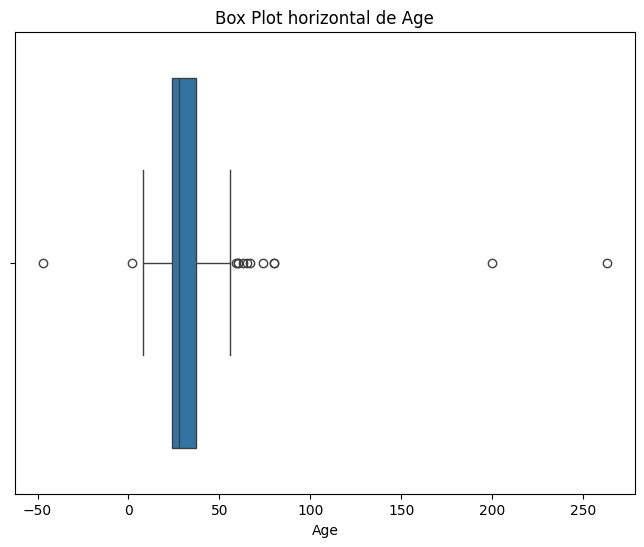

In [9]:
# .- Generación de un 'Box Plot' para columnas numéricas.
print("Grafico 'Box Plot' de cada columna numérica:")

for col in num_cols:

    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot horizontal de {col}')
    plt.xlabel(col)
    plt.show()

Con la generación del grafico 'Box Plot', en este caso a la columna de 'Age', logramos identificar de manera mas explicita que se presentan Outliers en la columna.

Graficos 'Count Plots' de cada columna categórica:


/tmp/ipykernel_1682/2784956119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


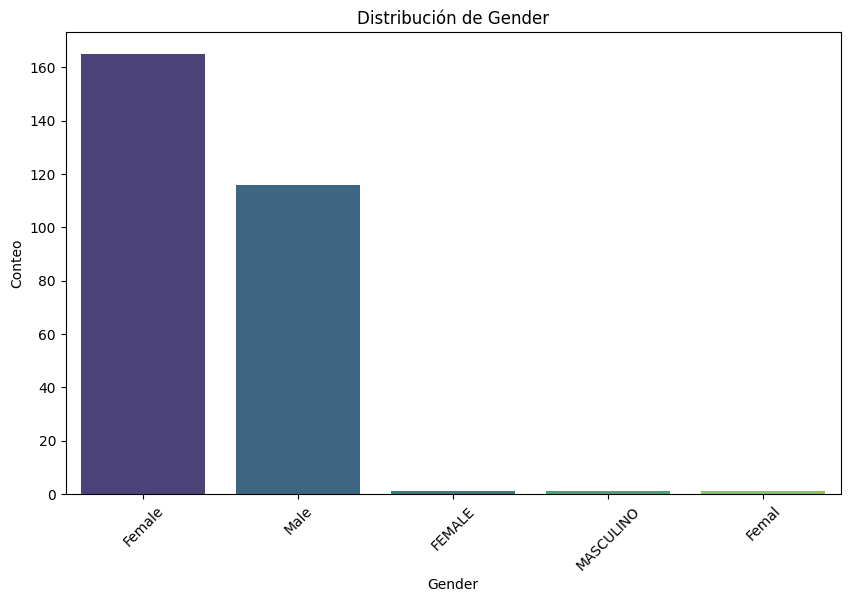

/tmp/ipykernel_1682/2784956119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


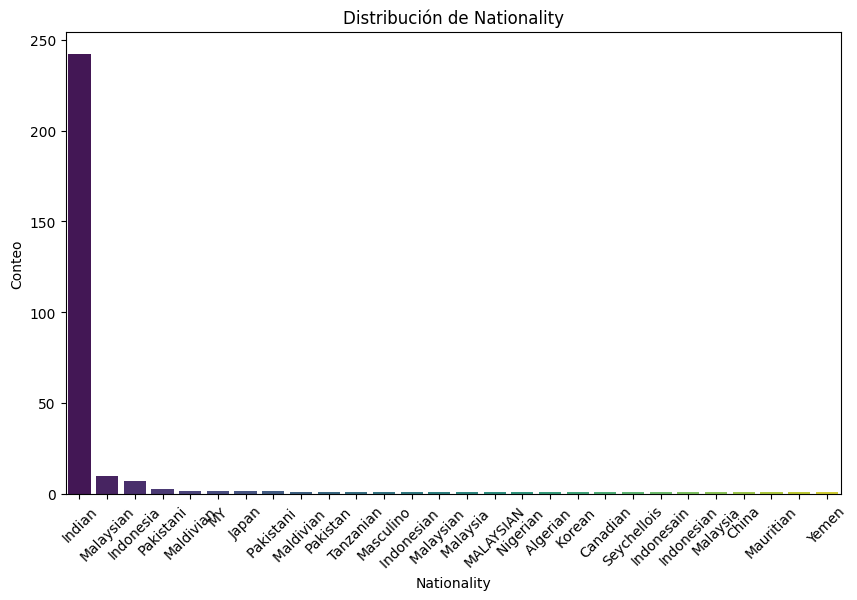

/tmp/ipykernel_1682/2784956119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


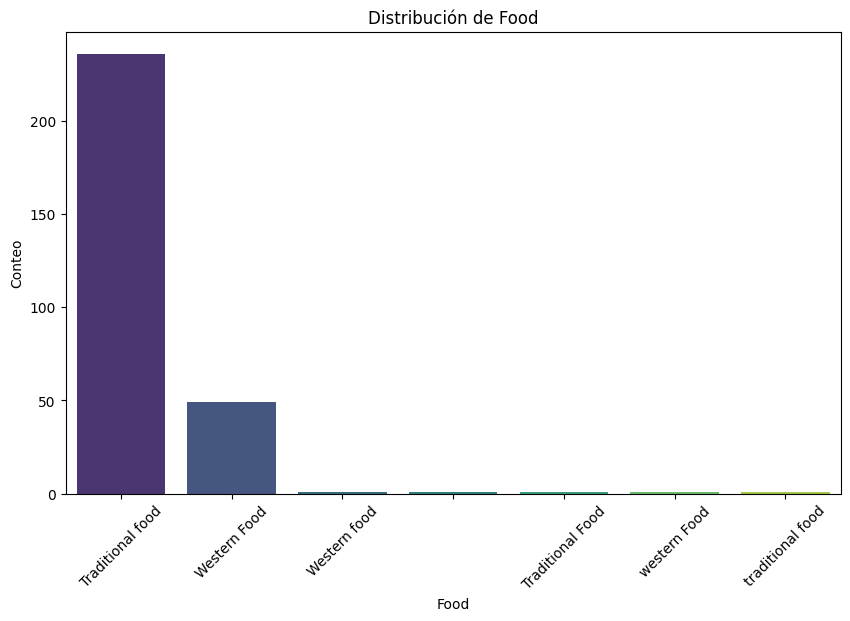

/tmp/ipykernel_1682/2784956119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


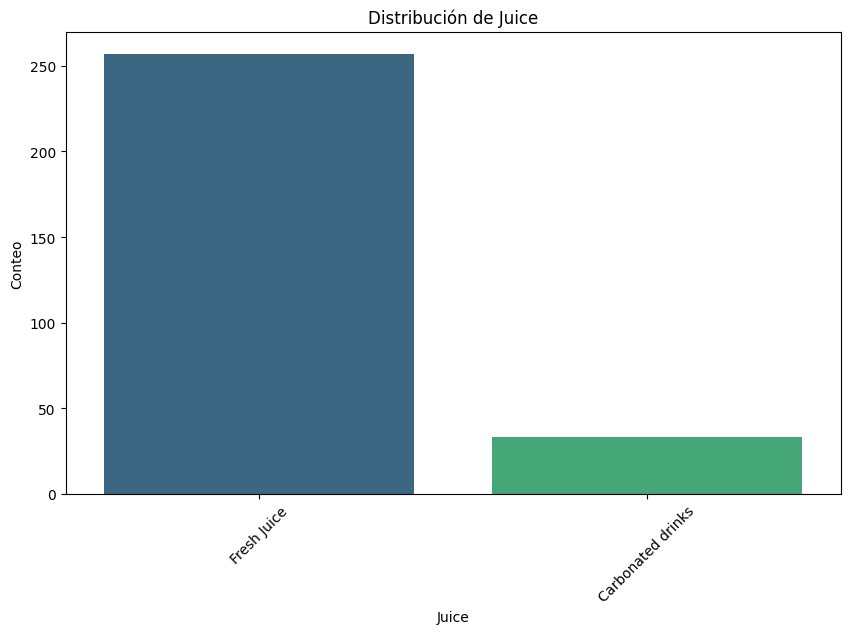

/tmp/ipykernel_1682/2784956119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


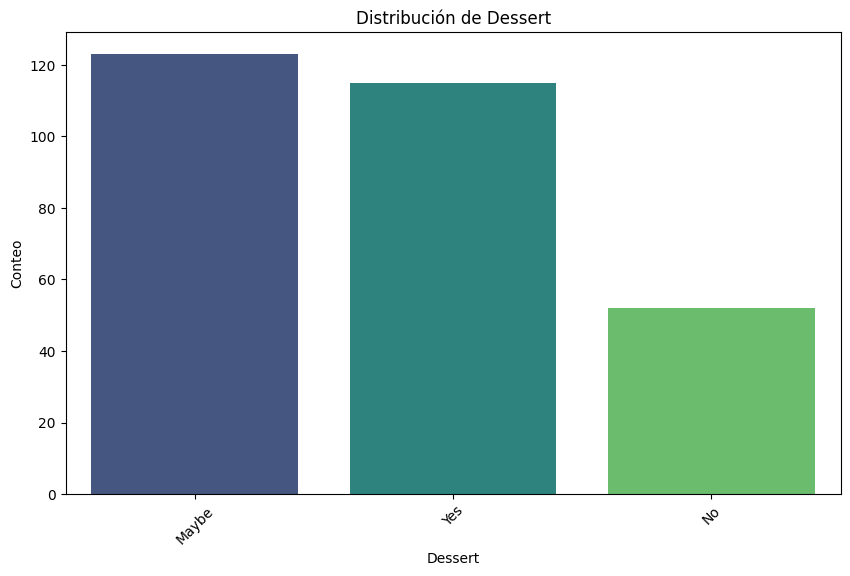

In [10]:
# .- Generación de 'Count Plots' verticales para columnas categóricas.
print("Graficos 'Count Plots' de cada columna categórica:")

for col in cat_cols:

    if col not in ['Timestamp', 'Participant_ID']:

        plt.figure(figsize=(10, 6))
        sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Distribución de {col}')
        plt.xlabel(col)
        plt.ylabel('Conteo')
        plt.xticks(rotation=45)
        plt.show()

Con la generación de los graficos 'Count Plots', en este caso de las columnas 'Gender', 'Nationality', 'Food', 'Juice' y 'Dessert', logramos identificar de manera mas explicita los valores que tienen registrados en cada columna, concluyendo que en varias columnas se ecnuentran errores en los datos registrados.

#**2.- Manipulación de Datos**

In [11]:
# .- Identificación de columnas relevantes para utilizar.
cols_relevantes = [
    'Participant_ID',
    'Gender',
    'Nationality',
    'Age',
    'Food',
    'Juice',
    'Dessert'
  ]

# .- Creación de copia independiente de los datos.
df = df[cols_relevantes].copy()

display(df.head())

,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
0,FPS001,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,FPS003,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,FPS004,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


Con la identificación de las columnas relevantes podremos realizar una manipulación de datos mas precisa.

Se escogieron estas columnas ya que, con el analisis realizado con anterioridad, se determino que estas son las columnas en la que abra mayor enfasis.

In [12]:
# .- Consulta rapida para verificar la cantidad de filas.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Participant_ID  290 non-null    object 
 1   Gender          284 non-null    object 
 2   Nationality     290 non-null    object 
 3   Age             288 non-null    float64
 4   Food            290 non-null    object 
 5   Juice           290 non-null    object 
 6   Dessert         290 non-null    object 
dtypes: float64(1), object(6)
memory usage: 16.0+ KB


In [13]:
# .- Nuevo registro para validar la concatenación simple.
data_adicional = {
    'Participant_ID': [9999],
    'Gender': ['Female'],
    'Nationality': ['Indian'],
    'Age': [22],
    'Food': ['Vegetarian'],
    'Juice': ['Fresh Juice'],
    'Dessert': ['Maybe']
  }

df_nuevo_lote = pd.DataFrame(data_adicional)

# .- Concatenar sobre los datos.
df = pd.concat([df, df_nuevo_lote], ignore_index=True)

# .- Verificación directa de la operación.
print("Estado de la manipulacion:")
print(f"Total registros después de integrar nuevos datos: {len(df)}")

Estado de la manipulacion:
Total registros después de integrar nuevos datos: 291


In [14]:
#.- Consulta para ver si se ingreso correctamente en todas las columnas la fila nueva
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Participant_ID  291 non-null    object 
 1   Gender          285 non-null    object 
 2   Nationality     291 non-null    object 
 3   Age             289 non-null    float64
 4   Food            291 non-null    object 
 5   Juice           291 non-null    object 
 6   Dessert         291 non-null    object 
dtypes: float64(1), object(6)
memory usage: 16.0+ KB


Este proceso no fue necesario, pero se agrega como un extra.

Se realiza un registro nuevo directamente en los datos para validar si es que es posible integrar nuevos datos sobre esta.

#**3.- Limpieza**

In [15]:
# .- Eliminación de filas duplicadas.
print(f'Tamaño del set antes de eliminar las filas repetidas: {df.shape}')

df.drop_duplicates(inplace=True)

print(f'Tamaño del set después de eliminar las filas repetidas: {df.shape}')

Tamaño del set antes de eliminar las filas repetidas: (291, 7)
Tamaño del set después de eliminar las filas repetidas: (289, 7)


Con las filas duplicadas ya eliminadas, podremos seguir adelante con la limpieza de datos. Estas filas duplicadas, si no eran eliminadas, puede que en el futuro influya en los procesos a hacer.

In [16]:
# .- Filtrado de columnas nuevamente para visualizar las columas relevantes.
cols_relevantes = ['Gender', 'Nationality', 'Age', 'Food', 'Juice', 'Dessert']

df = df[cols_relevantes].copy()

display(df.head())

,Gender,Nationality,Age,Food,Juice,Dessert
0,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe
5,NaN,Indian,27.0,Traditional food,Fresh Juice,Maybe


In [17]:
# .- Verificación nuevamente de valores faltantes en columnas.
df.isnull().sum()

,0
Gender,6
Nationality,0
Age,2
Food,0
Juice,0
Dessert,0


Con la visualización de datos nuevamente, verificamos que sean los mismo que se presentaron en la etapa de analisis. Mayormente se vuelven a presentar para confirmar lo planteado.

Como información extra dentro de la limpieza, se opto con sacar la columna de 'Participant_ID', ya que no influye dentro de la limpieza de datos y procesos futuros.

In [18]:
# .- Conversión de valores.

# .- Edades negativas.
df['Age'] = df['Age'].abs()

print("Valores en la columna 'Age' después de la transformación (primeras 5 filas):")
print(df['Age'].head())

# .- Verificación de edades negativas.
negative_ages = df[df['Age'] < 0].shape[0]
print(f"\nNúmero de edades negativas después de la transformación: {negative_ages}")
print("\nEstadísticas descriptivas de la columna 'Age':")
print(df['Age'].describe())

Valores en la columna 'Age' después de la transformación (primeras 5 filas):
0    24.0
1    22.0
3    31.0
4    25.0
5    27.0
Name: Age, dtype: float64

Número de edades negativas después de la transformación: 0

Estadísticas descriptivas de la columna 'Age':
count    287.000000
mean      31.975610
std       20.369045
min        2.000000
25%       24.000000
50%       28.000000
75%       37.000000
max      263.000000
Name: Age, dtype: float64


Con esta secuencia de codigos logramos identificar yu eliminar las filas que en la columna de 'Age' presentaban un valor nulo.

In [19]:
# .- Integración de promedio a valores nulos.
df['Age'] = df['Age'].fillna(df['Age'].mean())

# .- Columnas categóricas.
cols_categoricas = ['Gender', 'Nationality', 'Food', 'Juice', 'Dessert']

for col in cols_categoricas:
    df[col] = df[col].fillna(df[col].mode()[0])

# .- Verificación de si se presentan valores nulos.
print("Valores nulos por columna después de imputación:")
print(df.isnull().sum())

Valores nulos por columna después de imputación:
Gender         0
Nationality    0
Age            0
Food           0
Juice          0
Dessert        0
dtype: int64


Ya con los valores negativos trabajados, dentro de la misma columna de 'Age', se tomaron los valores nulos y fueron reemplazados por el valor promedio de todas las edades registradas.

Para finalizar se vuelve a hace una visualización completa de todas las columnas para verificar que no presenten valores nulos, en este caso, se logro establecer lo indicado.

Generando Box Plots para columnas numéricas:


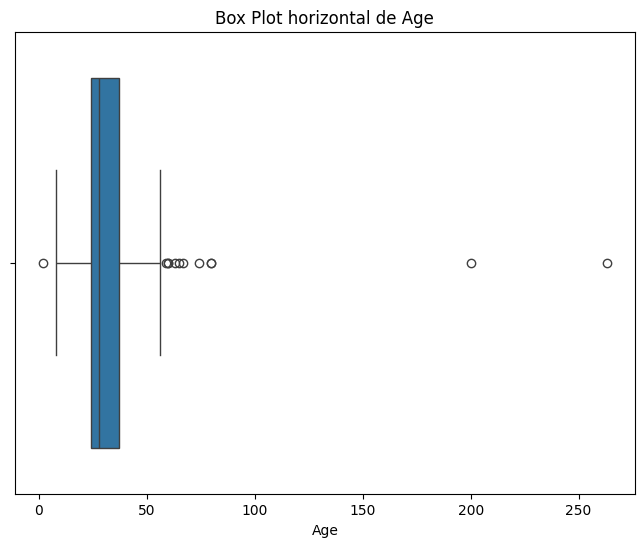

In [20]:
# .- Generación de 'Box Plot'.
print("Generando Box Plots para columnas numéricas:")
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot horizontal de {col}')
    plt.xlabel(col)
    plt.show()

/tmp/ipykernel_1682/3861632285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


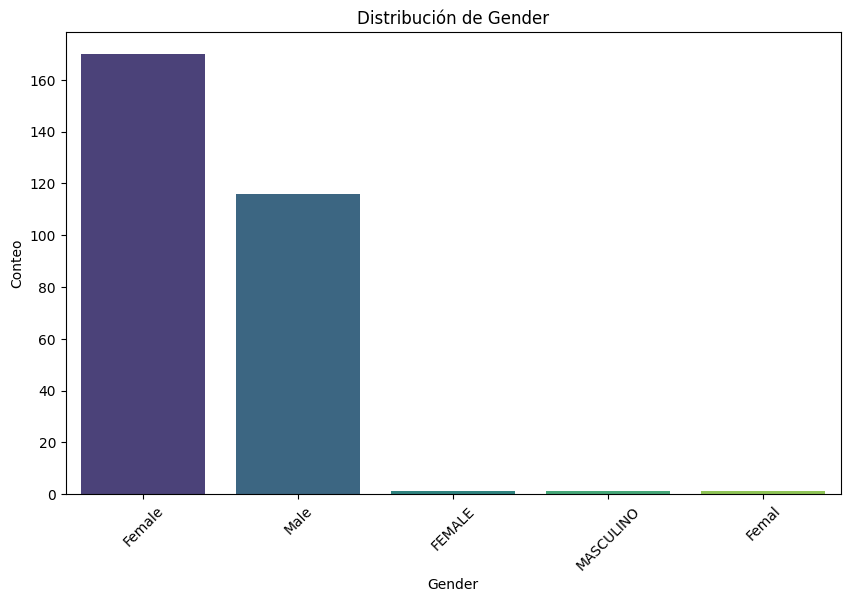

/tmp/ipykernel_1682/3861632285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


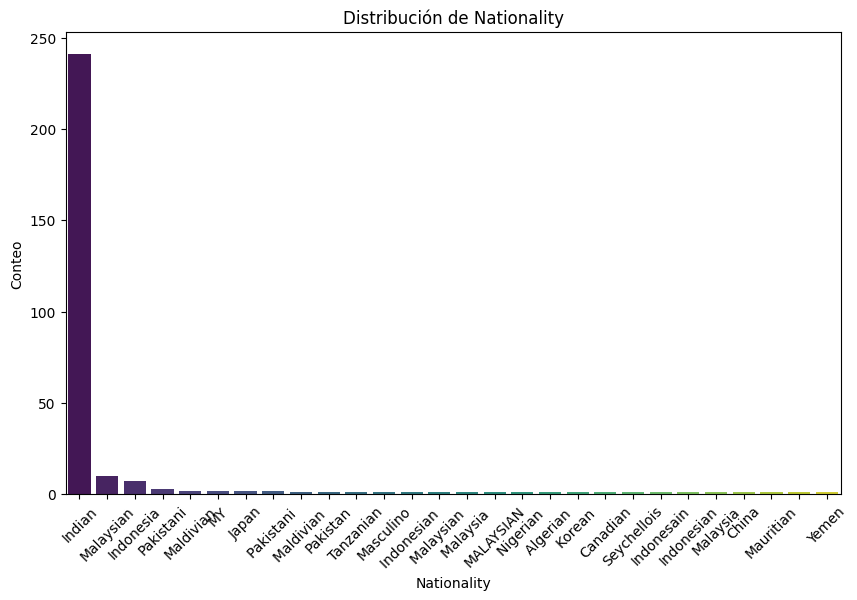

/tmp/ipykernel_1682/3861632285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


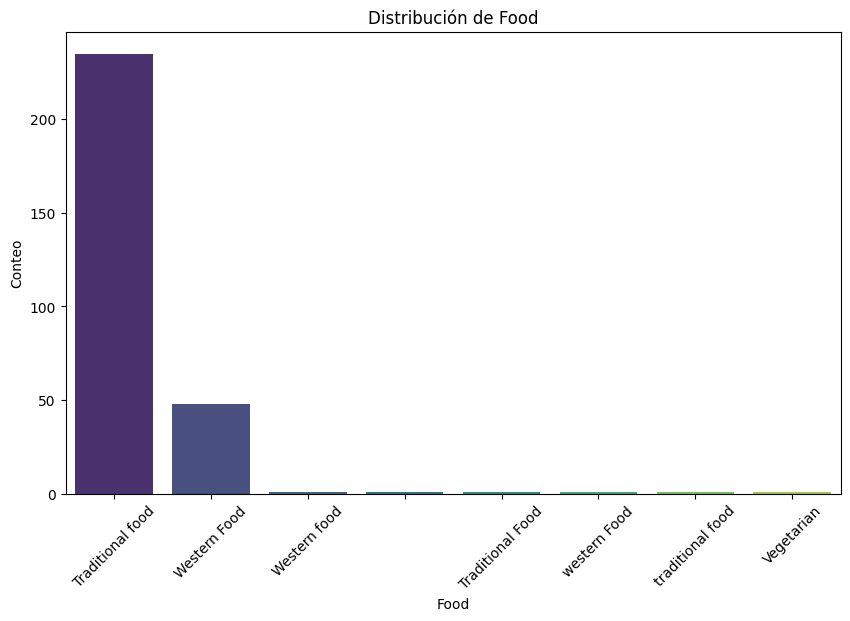

/tmp/ipykernel_1682/3861632285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


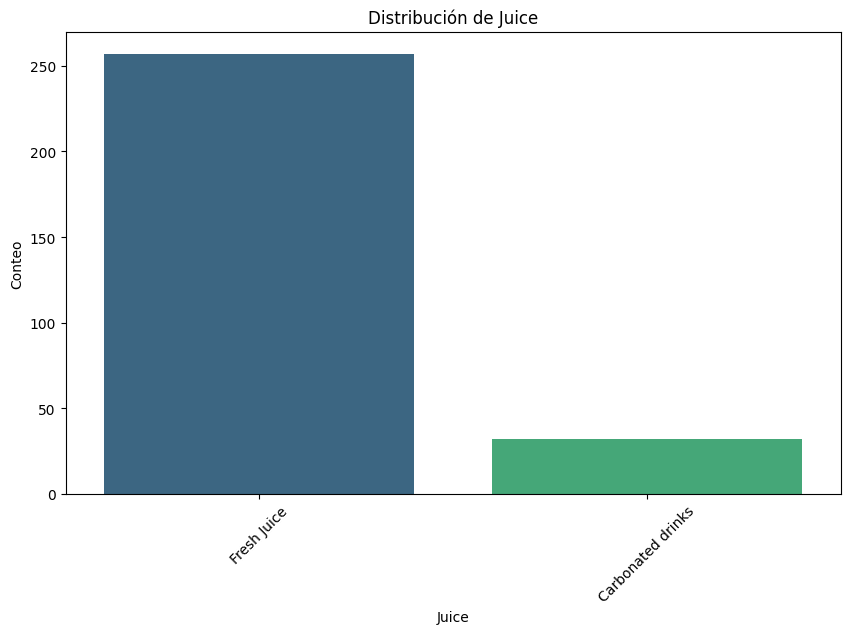

/tmp/ipykernel_1682/3861632285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


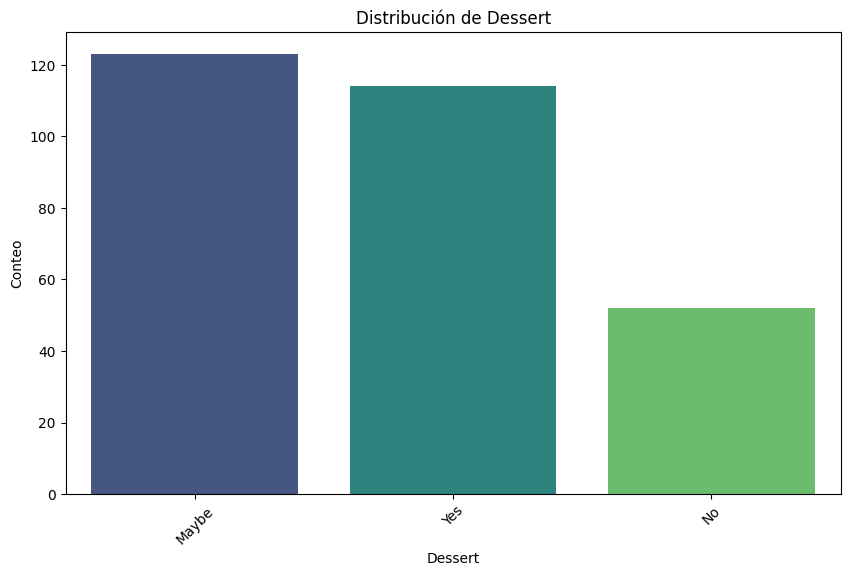

In [21]:
# Generación de 'Count Plots' verticales.
for col in cat_cols:
    if col not in ['Timestamp', 'Participant_ID']:  # Excluir columnas con demasiados valores únicos
        plt.figure(figsize=(10, 6))
        sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Distribución de {col}')
        plt.xlabel(col)
        plt.ylabel('Conteo')
        plt.xticks(rotation=45)
        plt.show()

Con la reevaluación de las graficas podemos concluir que:

1. Dentro de los valores de 'Age', aun se presentan datos que se encuentran fuera del rango común visto.

2. Independietemente de que se hayan eliminado los valores nulos de las columnas, se pueden identificar aun valor, que a la vista quisieran ser nulos, pero son valores con registros vacios, en otras palabras, Stringvacios.

Q1 (25%): 24.0
Q3 (75%): 37.0
IQR: 13.0
Límite inferior: 4.5
Límite superior: 56.5

Registros antes: 289
Registros después: 277
Outliers detectados: 12


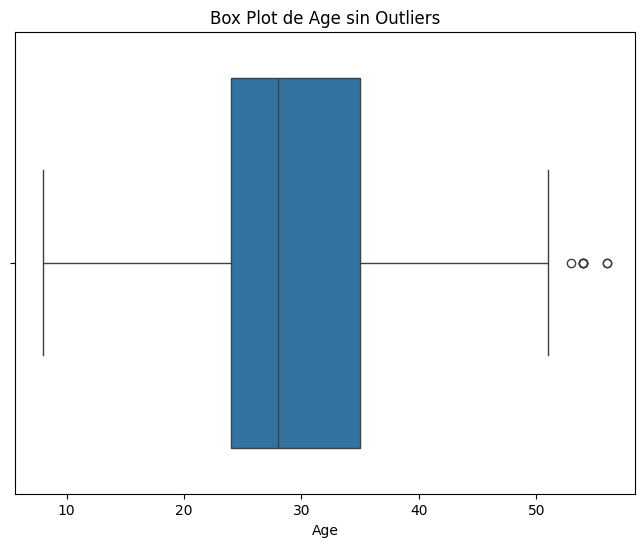


DataFrame actualizado sin outliers en 'Age'


In [22]:
# Calcular cuartiles
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

# Rango intercuartílico
IQR = Q3 - Q1

# Límites
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25%): {Q1}")
print(f"Q3 (75%): {Q3}")
print(f"IQR: {IQR}")
print(f"Límite inferior: {lower_bound}")
print(f"Límite superior: {upper_bound}")


# FILTRADO (sin modificar df aún)
df_no_outliers = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)].copy()

print(f"\nRegistros antes: {len(df)}")
print(f"Registros después: {len(df_no_outliers)}")
print(f"Outliers detectados: {len(df) - len(df_no_outliers)}")

plt.figure(figsize=(8, 6))
sns.boxplot(x=df_no_outliers['Age'])
plt.title('Box Plot de Age sin Outliers')
plt.xlabel('Age')
plt.show()

# .- Para eliminar los outliers
df = df_no_outliers.copy()

print("\nDataFrame actualizado sin outliers en 'Age'")

In [23]:
df.describe()

,Age
count,277.000000
mean,29.487189
std,9.025520
min,8.000000
25%,24.000000
50%,28.000000
75%,35.000000
max,56.000000


Gracias a esta secuencia de codigos, podemos establecer un rango mas correcto dentro de la columna de 'Age'. Para una mayor confirmación de la ejecución correcta del codigo anterior, se opto por realizar la función '.describe()'.

Columnas a convertir a minúsculas: ['Gender', 'Nationality', 'Food', 'Juice', 'Dessert']

Datos después de conversión a minúsculas:


,Gender,Nationality,Age,Food,Juice,Dessert
0,female,indian,24.0,traditional food,fresh juice,maybe
1,female,indian,22.0,western food,carbonated drinks,yes
3,male,indian,31.0,western food,fresh juice,maybe
4,female,indian,25.0,traditional food,fresh juice,maybe
5,female,indian,27.0,traditional food,fresh juice,maybe


/tmp/ipykernel_1682/823836660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


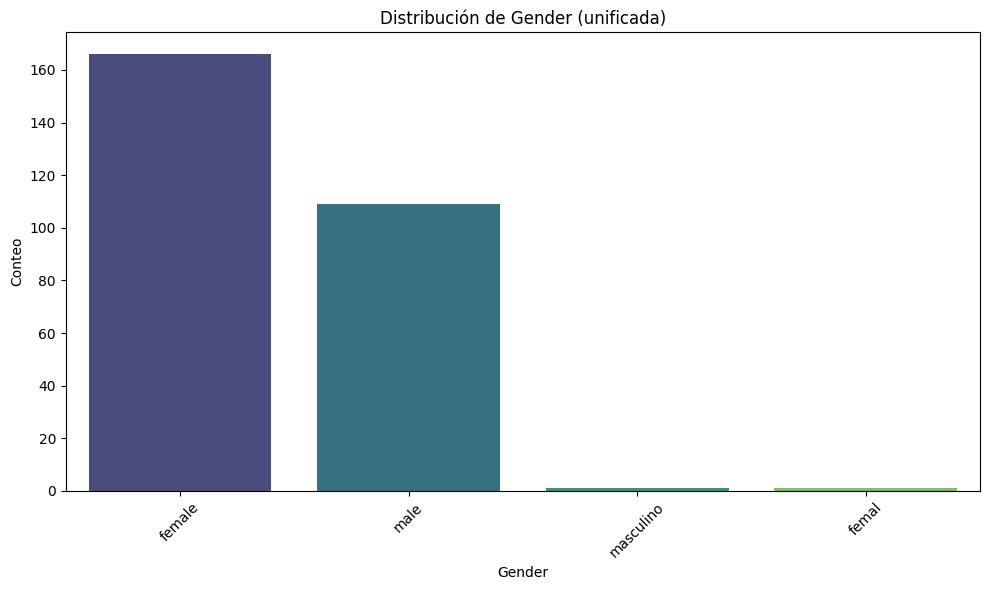

/tmp/ipykernel_1682/823836660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


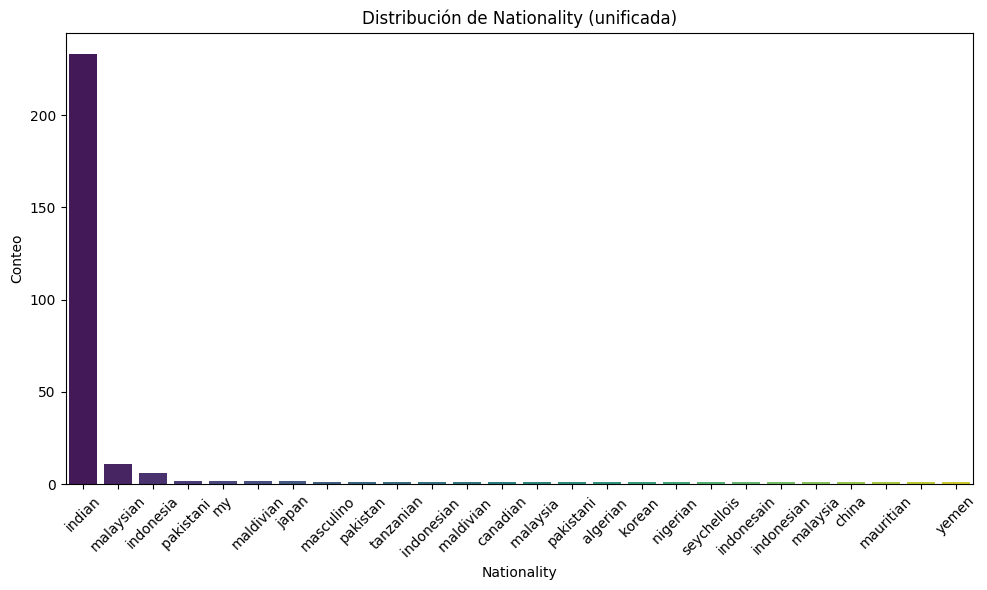

/tmp/ipykernel_1682/823836660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


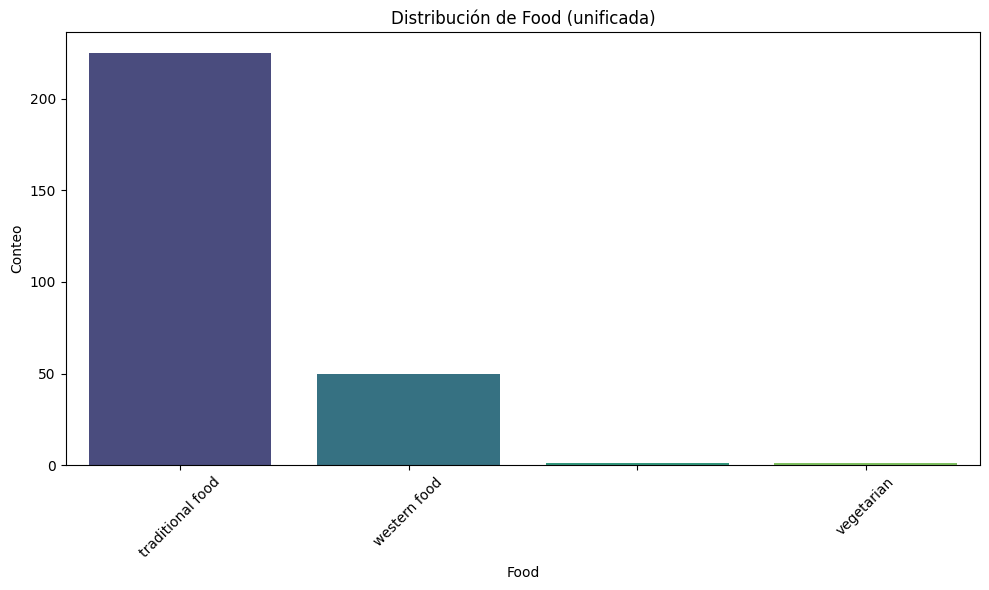

/tmp/ipykernel_1682/823836660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


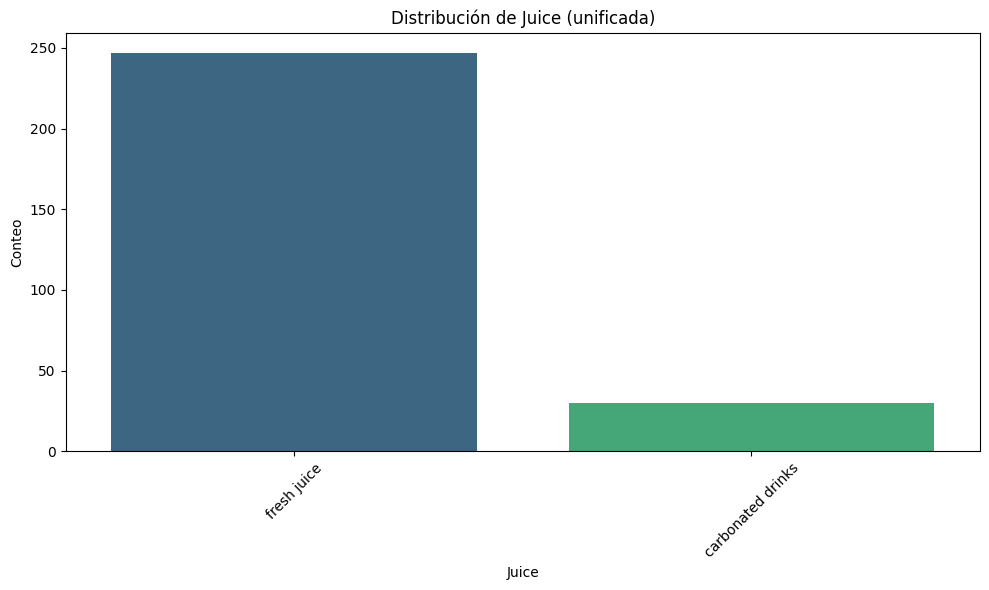

/tmp/ipykernel_1682/823836660.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


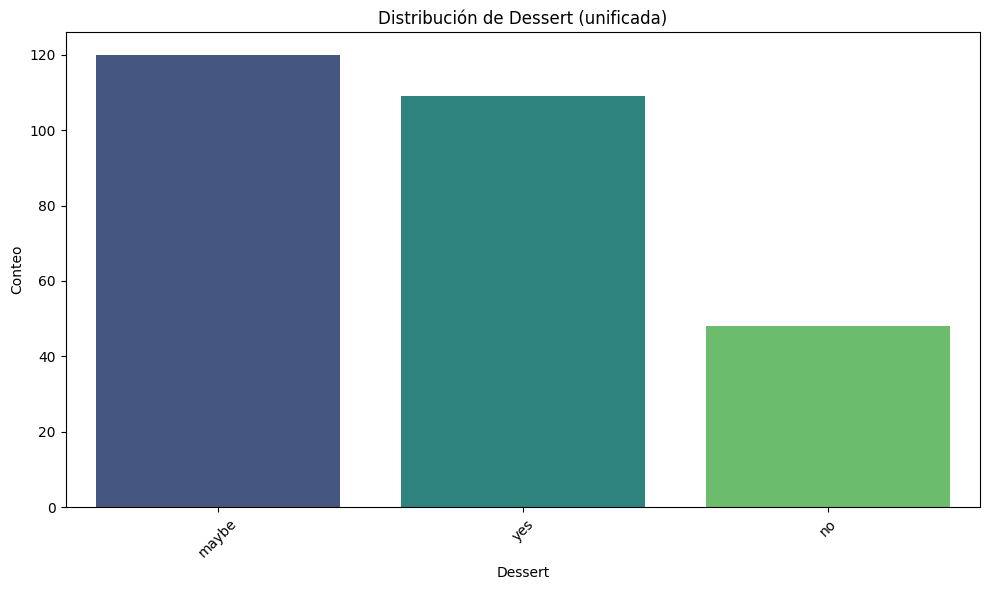

In [24]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Columnas a convertir a minúsculas:", categorical_cols)

for col in categorical_cols:
    df[col] = df[col].apply(lambda x: str(x).lower() if pd.notna(x) else np.nan)

print("\nDatos después de conversión a minúsculas:")
display(df.head())

for col in categorical_cols:
    if col != 'Participant_ID':
        plt.figure(figsize=(10, 6))
        sns.countplot(
            x=df[col],
            order=df[col].value_counts().index,
            palette='viridis'
        )
        plt.title(f'Distribución de {col} (unificada)')
        plt.xlabel(col)
        plt.ylabel('Conteo')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

Para lograr una mejor limpieza de datos, se establece que las columnas que son categoricas, necesitan estar a un mismo nivel para trabajar con ellas y por lo que se opto fue establecer todos los valores de estas columnas en minusculas.

¿Porque es necesario dejarlas todas a un mismo nivel?

Porque a la hora de transformar los valores, logramos que estos se junten en un valor en comun, como por ejemplo: dentro de la columna de 'Gender' se daba el caso de que unas de las filas registradas presentaban algo en común, que tenian un registro de 'female', pero una de estas era presentada con mayuscula.

El ejemplo de 'Gender' fue solo uno, pero gracias a los graficos podemos identificar todos los que hay. Ahora se trabajara en cada columna respectiva para realizar los cambias y poder tener los datos de manera clara.

# **.- Genero. **

Valores únicos de la columna 'Gender' después de la unificación:
['female' 'male']


/tmp/ipykernel_1682/593347504.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Gender'], order=df['Gender'].value_counts().index, palette='viridis')


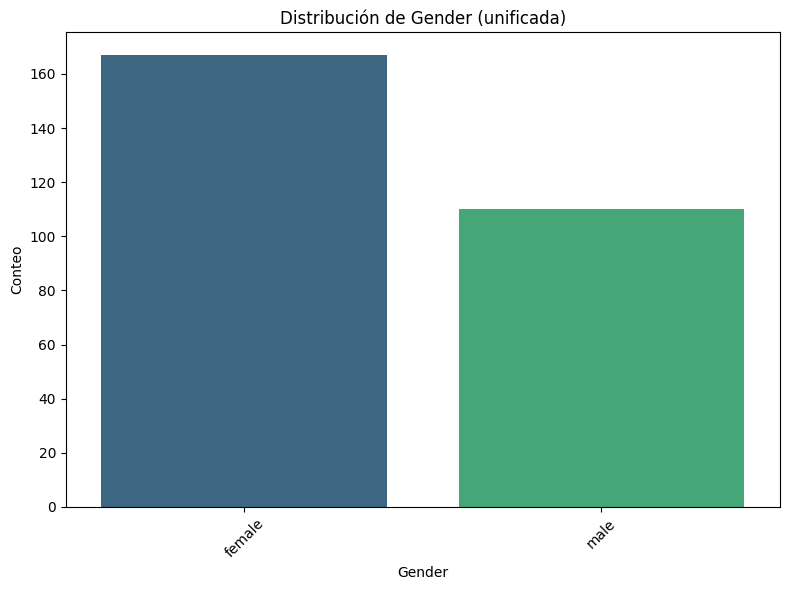

In [25]:
# .- Corregir errores tipográficos en variables categóricas.
df['Gender'] = df['Gender'].replace({
    'femal': 'female',
    'masculino': 'male'
})

print("Valores únicos de la columna 'Gender' después de la unificación:")
print(df['Gender'].dropna().unique())

# Generar Count Plot vertical para la columna 'Gender' actualizada
plt.figure(figsize=(8, 6))
sns.countplot(x=df['Gender'], order=df['Gender'].value_counts().index, palette='viridis')
plt.title('Distribución de Gender (unificada)')
plt.xlabel('Gender')
plt.ylabel('Conteo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Lo sucedido con la columna de 'Gender' era que se presentaban valores con el mismo sentido, pero escritos de manera erronea. Con el codigo anterior logramos establecer los valores comunes que se trabajan en la columna.

#**.- Comida.**

/tmp/ipykernel_1682/3491926916.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Food'], order=df['Food'].value_counts().index, palette='viridis')


Moda de 'Food': traditional food

Valores únicos en 'Food' después de reemplazo:
['traditional food' 'western food' 'vegetarian']


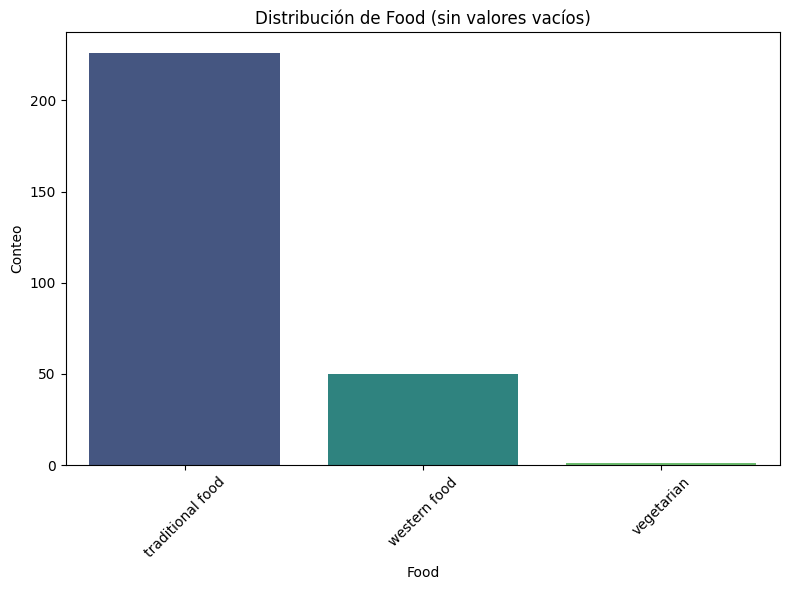

In [26]:
# .- String vacios a valores nulos.
df['Food'] = df['Food'].replace(['', ' '], np.nan)

# .- Identifdicar la moda.
moda_food = df['Food'].mode()[0]
print("Moda de 'Food':", moda_food)

# .- Reemplazar nulos por la moda.
df['Food'] = df['Food'].fillna(moda_food)

# .- Indentificar los valores finales.
print("\nValores únicos en 'Food' después de reemplazo:")
print(df['Food'].unique())

plt.figure(figsize=(8, 6))
sns.countplot(x=df['Food'], order=df['Food'].value_counts().index, palette='viridis')
plt.title('Distribución de Food (sin valores vacíos)')
plt.xlabel('Food')
plt.ylabel('Conteo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El analisis anterior nos mostraba que en la columna de 'Food' aun se presentaba un valor "nulo". Con el codigo anterior identificamos que era un string vacio y se opto por tranaformarlo a un valor nulo, para asi, establecer ese vcalor con la moda de las comidas.

#**.- Nacionalidad**

Moda de 'Nationality': indian

Conteo por nacionalidad:
Nationality
indian         235
malaysian       15
indonesian       9
pakistani        4
maldivian        3
japanese         2
tanzanian        1
canadian         1
nigerian         1
korean           1
algerian         1
seychellois      1
chinese          1
mauritian        1
yemen            1
Name: count, dtype: int64


/tmp/ipykernel_1682/3480729866.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Nationality'], order=df['Nationality'].value_counts().index, palette='viridis')


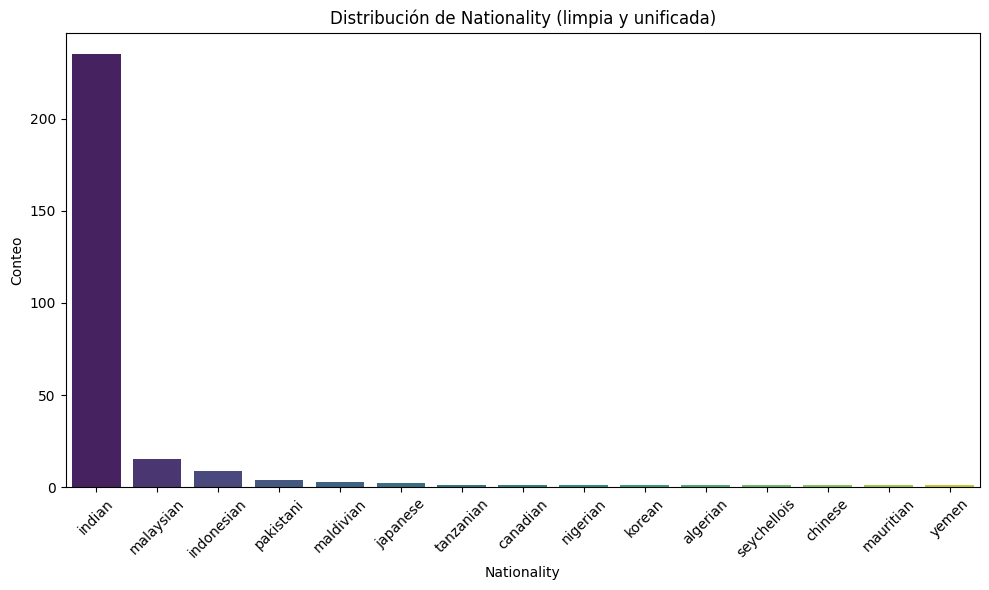

In [27]:
# .- Normalizar texto.
df['Nationality'] = df['Nationality'].astype(str).str.strip().str.lower()

# .- String vacios a valores nulos.
df['Nationality'] = df['Nationality'].replace(['', 'nan'], np.nan)

# .- Unificar valores.
df['Nationality'] = df['Nationality'].replace({
    'indonesia': 'indonesian',
    'indonesain': 'indonesian',
    'pakistan': 'pakistani',
    'malaysia': 'malaysian',
    'my': 'malaysian',
    'japan': 'japanese',
    'china': 'chinese',
    'masculino': np.nan
})

# .- Identifdicar la moda.
moda_nat = df['Nationality'].mode()[0]
print("Moda de 'Nationality':", moda_nat)

# .- Reemplazar nulos por la moda.
df['Nationality'] = df['Nationality'].fillna(moda_nat)

# .- Verificación dada un conteo.
print("\nConteo por nacionalidad:")
print(df['Nationality'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(x=df['Nationality'], order=df['Nationality'].value_counts().index, palette='viridis')
plt.title('Distribución de Nationality (limpia y unificada)')
plt.xlabel('Nationality')
plt.ylabel('Conteo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

En una etapa temprana sobre el analisis, se lograban visualizar muchas nacionalidades las cuales algunas eran correctas, mientras que otras eran erroneas, pero a diferencia de otras columnas que presentaban este mismo problema en común, esta presentaba valores correctos pero sumado a string vacios. Gracias al codigo se pudo arregalr esa preocupación extra, mas el problema común.

# **4.- Transformación.**

In [31]:
numeric_features = ['Age']
categorical_features = ['Gender', 'Nationality', 'Food', 'Juice', 'Dessert']

# .- Pipeline para variables numéricas.
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),  # reemplaza valores faltantes
        ("scaler", StandardScaler())  # escala los datos
    ]
)

# .- Pipeline para variables categóricas.
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # por si queda algún NaN
        ("encoder", OneHotEncoder(handle_unknown="ignore"))  # codificación
    ]
)

# .- Unión de datos.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

X = df[numeric_features + categorical_features]
X_processed = preprocessor.fit_transform(X)
feature_names_out = preprocessor.get_feature_names_out()
X_processed_df = pd.DataFrame(X_processed.toarray(), columns=feature_names_out)
print("Primeras filas del dataset procesado:")
display(X_processed_df.head(20))

Primeras filas del dataset procesado:


,num__Age,cat__Gender_female,cat__Gender_male,cat__Nationality_algerian,cat__Nationality_canadian,cat__Nationality_chinese,cat__Nationality_indian,cat__Nationality_indonesian,cat__Nationality_japanese,cat__Nationality_korean,...,cat__Nationality_tanzanian,cat__Nationality_yemen,cat__Food_traditional food,cat__Food_vegetarian,cat__Food_western food,cat__Juice_carbonated drinks,cat__Juice_fresh juice,cat__Dessert_maybe,cat__Dessert_no,cat__Dessert_yes
0,-0.609064,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,-0.831059,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
2,0.167918,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
3,-0.498067,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,-0.276072,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
5,-0.609064,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
6,0.500911,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
7,-0.609064,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
8,-1.164052,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
9,-1.497044,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


El pipeline se utiliza para automatizar el preprocesamiento de la variable Age, imputando valores faltantes y aplicando escalamiento. Esto permite realizar estas transformaciones de forma ordenada y consistente sin intervención manual.

#**5.- Exportación.**

In [29]:
# .- Creación del df final para la exportación.
df_final = df.copy()

# .- Guardar df final en un archivo csv nuevo.
df_final.to_csv("Food_Preference_final.csv", index=False)

In [30]:
df_final.head()

,Gender,Nationality,Age,Food,Juice,Dessert
0,female,indian,24.0,traditional food,fresh juice,maybe
1,female,indian,22.0,western food,carbonated drinks,yes
3,male,indian,31.0,western food,fresh juice,maybe
4,female,indian,25.0,traditional food,fresh juice,maybe
5,female,indian,27.0,traditional food,fresh juice,maybe
